In [1]:
import pandas as pd
import numpy as np

In [3]:
# display all columns
pd.set_option("display.max_columns", None)

# display full clolumn content
pd.set_option("display.max_colwidth", None)

# Increase notebook display width
pd.set_option("display.width", 200)

In [7]:
df = pd.read_csv("../data/raw/obesity.csv")
df.sample(5)

C:\Users\sidgu\AppData\Local\Temp\ipykernel_26104\1138909850.py:1: DtypeWarning: Columns (0: Data_Value_Unit) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/obesity.csv")


,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,Total,Age(years),Education,Sex,Income,Race/Ethnicity,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
109450,2024,2024,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who have an overweight classification,%,Value,35.7,35.7,NaN,NaN,33.0,38.4,1944.0,NaN,NaN,NaN,NaN,Data not reported,NaN,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q037,VALUE,1,Income,Data not reported,INC,INCNR
26043,2013,2013,WY,Wyoming,Behavioral Risk Factor Surveillance System,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-time physical activity,NaN,Value,19.7,19.7,NaN,NaN,16.5,23.2,945.0,NaN,NaN,NaN,NaN,"$50,000 - $74,999",NaN,"(43.235541343, -108.109830353)",PA,PA1,Q047,VALUE,56,Income,"$50,000 - $74,999",INC,INC5075
14778,2012,2012,NY,New York,Behavioral Risk Factor Surveillance System,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-time physical activity,NaN,Value,21.6,21.6,NaN,NaN,19.3,24.0,2454.0,NaN,NaN,NaN,Male,NaN,NaN,"(42.827001032, -75.543970427)",PA,PA1,Q047,VALUE,36,Sex,Male,SEX,MALE
63332,2018,2018,CT,Connecticut,Behavioral Risk Factor Surveillance System,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-time physical activity,NaN,Value,20.0,20.0,NaN,NaN,18.8,21.3,8327.0,NaN,NaN,NaN,NaN,NaN,Non-Hispanic White,"(41.56266102, -72.649840952)",PA,PA1,Q047,VALUE,9,Race/Ethnicity,Non-Hispanic White,RACE,RACEWHT
23635,2013,2013,ME,Maine,Behavioral Risk Factor Surveillance System,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in muscle-strengthening activities on 2 or more days a week,NaN,Value,33.7,33.7,NaN,NaN,30.2,37.3,1172.0,NaN,NaN,NaN,NaN,"$50,000 - $74,999",NaN,"(45.254228894001, -68.985031336)",PA,PA1,Q046,VALUE,23,Income,"$50,000 - $74,999",INC,INC5075


In [8]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum()/len(df)*100).round(2),
    "Unique Values": df.nunique()
})

missing.sort_values("Missing %", ascending=False)

,Missing Count,Missing %,Unique Values
Total,106920,96.43,1
Data_Value_Unit,106260,95.83,1
Sex,102960,92.86,2
Data_Value_Footnote,97666,88.08,1
Data_Value_Footnote_Symbol,97666,88.08,1
Education,95040,85.71,5
Age(years),87120,78.57,6
Income,83160,75.00,7
Race/Ethnicity,79200,71.43,8
Low_Confidence_Limit,13214,11.92,702


In [9]:
df["StratificationCategory1"].value_counts(dropna=False)

StratificationCategory1
Race/Ethnicity    31680
Income            27720
Age (years)       23760
Education         15840
Sex                7920
Total              3960
Name: count, dtype: int64

In [10]:
df[
    [
        "StratificationCategory1",
        "Stratification1",
        "Age(years)",
        "Education",
        "Sex",
        "Income",
        "Race/Ethnicity"
    ]
].sample(20, random_state=42)

,StratificationCategory1,Stratification1,Age(years),Education,Sex,Income,Race/Ethnicity
52777,Race/Ethnicity,Non-Hispanic Other,NaN,NaN,NaN,NaN,Non-Hispanic Other
51695,Age (years),25 - 34,25 - 34,NaN,NaN,NaN,NaN
32484,Income,"$75,000 or greater",NaN,NaN,NaN,"$75,000 or greater",NaN
32539,Income,"$50,000 - $74,999",NaN,NaN,NaN,"$50,000 - $74,999",NaN
52027,Income,"$50,000 - $74,999",NaN,NaN,NaN,"$50,000 - $74,999",NaN
31891,Total,Total,NaN,NaN,NaN,NaN,NaN
93188,Income,"$75,000 or greater",NaN,NaN,NaN,"$75,000 or greater",NaN
34342,Education,College graduate,NaN,College graduate,NaN,NaN,NaN
50944,Race/Ethnicity,NH American Indian/Alaska Native,NaN,NaN,NaN,NaN,NH American Indian/Alaska Native
186,Education,High school graduate,NaN,High school graduate,NaN,NaN,NaN


In [11]:
df.shape

(110880, 33)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110880 entries, 0 to 110879
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   YearStart                   110880 non-null  int64  
 1   YearEnd                     110880 non-null  int64  
 2   LocationAbbr                110880 non-null  str    
 3   LocationDesc                110880 non-null  str    
 4   Datasource                  110880 non-null  str    
 5   Class                       110880 non-null  str    
 6   Topic                       110880 non-null  str    
 7   Question                    110880 non-null  str    
 8   Data_Value_Unit             4620 non-null    str    
 9   Data_Value_Type             110880 non-null  str    
 10  Data_Value                  97666 non-null   float64
 11  Data_Value_Alt              97666 non-null   float64
 12  Data_Value_Footnote_Symbol  13214 non-null   str    
 13  Data_Value_Footnote      

In [13]:
df.describe()

,YearStart,YearEnd,Data_Value,Data_Value_Alt,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,LocationID
count,110880.000000,110880.000000,97666.000000,97666.000000,97666.000000,97666.000000,97666.000000,110880.000000
mean,2017.236111,2017.236111,31.800252,31.800252,27.395236,36.767070,3624.716831,31.854545
std,3.931702,3.931702,10.343087,10.343087,10.130335,11.282278,18583.467990,18.392194
min,2011.000000,2011.000000,0.900000,0.900000,0.300000,3.000000,50.000000,1.000000
25%,2014.000000,2014.000000,24.900000,24.900000,20.400000,29.200000,494.000000,17.000000
50%,2017.000000,2017.000000,31.800000,31.800000,27.300000,36.500000,1079.000000,31.000000
75%,2020.250000,2020.250000,37.400000,37.400000,33.300000,42.800000,2399.000000,46.000000
max,2024.000000,2024.000000,85.300000,85.300000,74.700000,92.400000,476876.000000,78.000000


In [14]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [15]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

YearStart: 14
YearEnd: 14
LocationAbbr: 55
LocationDesc: 55
Datasource: 1
Class: 3
Topic: 3
Question: 9
Data_Value_Unit: 1
Data_Value_Type: 1
Data_Value: 723
Data_Value_Alt: 723
Data_Value_Footnote_Symbol: 1
Data_Value_Footnote: 1
Low_Confidence_Limit: 702
High_Confidence_Limit : 790
Sample_Size: 10395
Total: 1
Age(years): 6
Education: 5
Sex: 2
Income: 7
Race/Ethnicity: 8
GeoLocation: 105
ClassID: 3
TopicID: 3
QuestionID: 9
DataValueTypeID: 1
LocationID: 55
StratificationCategory1: 6
Stratification1: 28
StratificationCategoryId1: 6
StratificationID1: 28


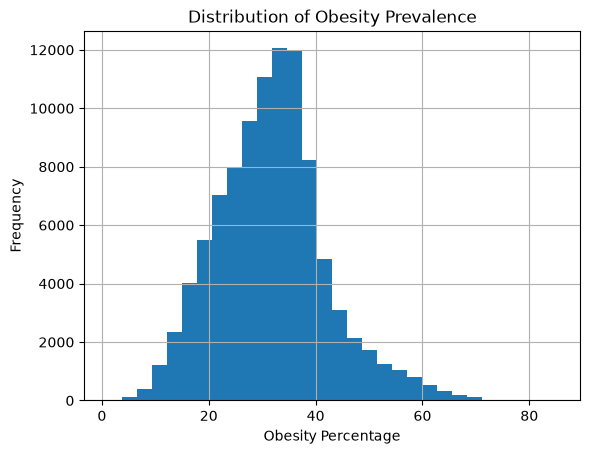

In [16]:
import matplotlib.pyplot as plt

df["Data_Value"].hist(bins=30)

plt.title("Distribution of Obesity Prevalence")
plt.xlabel("Obesity Percentage")
plt.ylabel("Frequency")

plt.show()

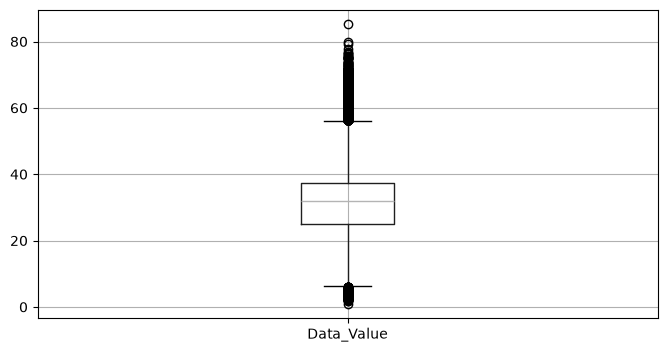

In [17]:
plt.figure(figsize=(8,4))

df.boxplot(column="Data_Value")

plt.show()

In [18]:
print(df["Data_Value"].skew())

0.4594236411103621


In [19]:
print(df["Data_Value"].kurt())

0.6629367602848091


In [20]:
numeric = df.select_dtypes(include=["int64","float64"])

numeric.corr(numeric_only=True)

,YearStart,YearEnd,Data_Value,Data_Value_Alt,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,LocationID
YearStart,1.000000e+00,1.000000e+00,0.093235,0.093235,0.076918,0.101005,-0.012287,2.004020e-14
YearEnd,1.000000e+00,1.000000e+00,0.093235,0.093235,0.076918,0.101005,-0.012287,2.004020e-14
Data_Value,9.323479e-02,9.323479e-02,1.000000,1.000000,0.956595,0.943432,-0.004803,6.350974e-03
Data_Value_Alt,9.323479e-02,9.323479e-02,1.000000,1.000000,0.956595,0.943432,-0.004803,6.350974e-03
Low_Confidence_Limit,7.691785e-02,7.691785e-02,0.956595,0.956595,1.000000,0.807927,0.051040,4.764169e-03
High_Confidence_Limit,1.010047e-01,1.010047e-01,0.943432,0.943432,0.807927,1.000000,-0.063047,8.587197e-03
Sample_Size,-1.228750e-02,-1.228750e-02,-0.004803,-0.004803,0.051040,-0.063047,1.000000,1.510527e-01
LocationID,2.004020e-14,2.004020e-14,0.006351,0.006351,0.004764,0.008587,0.151053,1.000000e+00


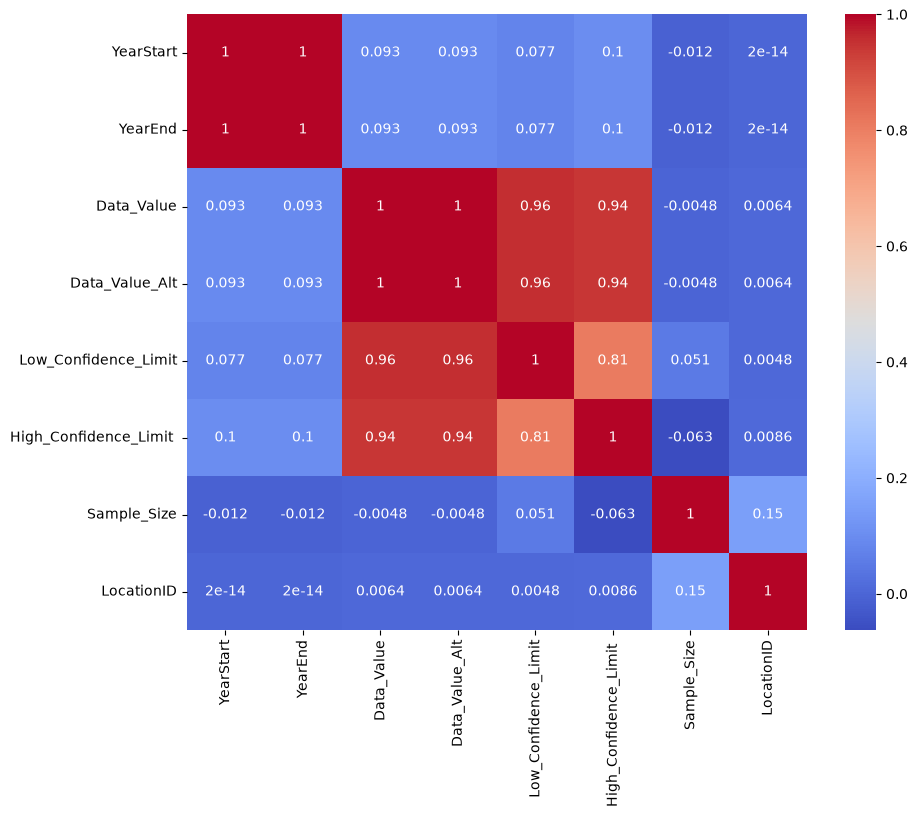

In [23]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

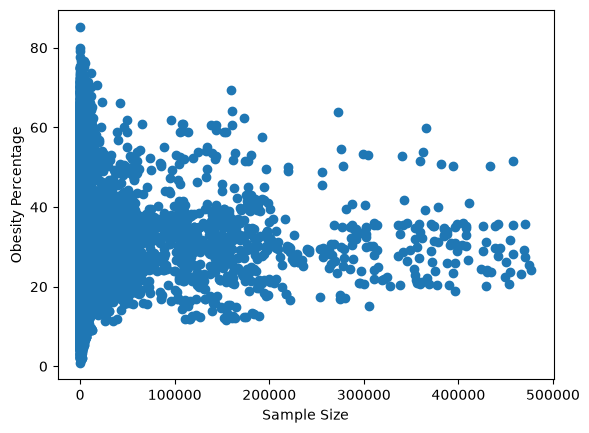

In [24]:
plt.scatter(df["Sample_Size"], df["Data_Value"])

plt.xlabel("Sample Size")
plt.ylabel("Obesity Percentage")

plt.show()

<Axes: xlabel='count', ylabel='Sex'>

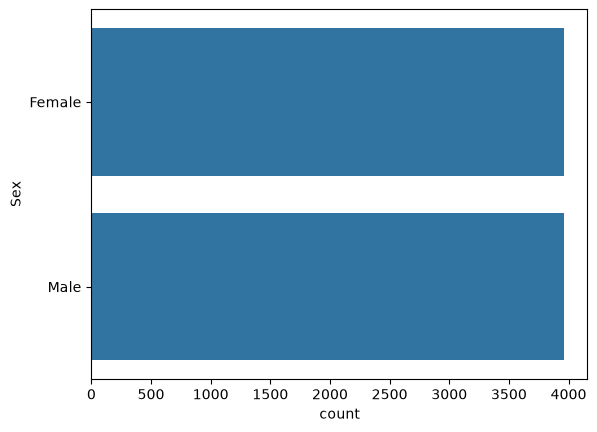

In [25]:
sns.countplot(data=df, y="Sex")

<Axes: xlabel='count', ylabel='Education'>

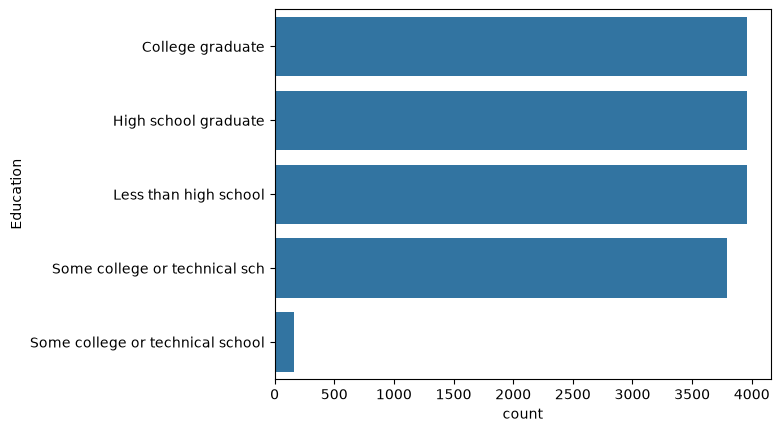

In [26]:
sns.countplot(data=df, y="Education")

<Axes: xlabel='Data_Value', ylabel='Count'>

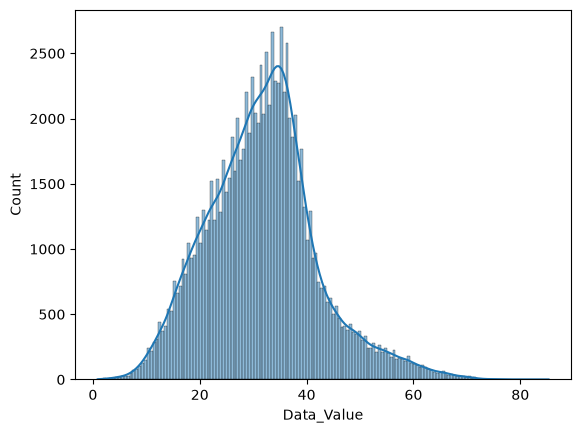

In [27]:
sns.histplot(df["Data_Value"], kde=True)

In [28]:
Q1 = df["Data_Value"].quantile(0.25)
Q3 = df["Data_Value"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Data_Value"] < lower) | (df["Data_Value"] > upper)]

print(outliers.shape)

(2496, 33)


In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

plt.style.use("ggplot")

In [30]:
df = pd.read_csv("../data/raw/obesity.csv")

df.head()

C:\Users\sidgu\AppData\Local\Temp\ipykernel_26104\2312561769.py:1: DtypeWarning: Columns (0: Data_Value_Unit) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/obesity.csv")


,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,Total,Age(years),Education,Sex,Income,Race/Ethnicity,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who have obesity,NaN,Value,34.8,34.8,NaN,NaN,31.3,38.5,1367.0,NaN,NaN,NaN,NaN,"$15,000 - $24,999",NaN,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$15,000 - $24,999",INC,INC1525
1,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who have obesity,NaN,Value,35.8,35.8,NaN,NaN,31.1,40.8,757.0,NaN,NaN,NaN,NaN,"$25,000 - $34,999",NaN,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$25,000 - $34,999",INC,INC2535
2,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who have obesity,NaN,Value,32.3,32.3,NaN,NaN,28.0,36.8,861.0,NaN,NaN,NaN,NaN,"$35,000 - $49,999",NaN,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$35,000 - $49,999",INC,INC3550
3,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who have obesity,NaN,Value,34.1,34.1,NaN,NaN,29.7,38.8,785.0,NaN,NaN,NaN,NaN,"$50,000 - $74,999",NaN,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$50,000 - $74,999",INC,INC5075
4,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who have obesity,NaN,Value,28.8,28.8,NaN,NaN,25.4,32.5,1125.0,NaN,NaN,NaN,NaN,"$75,000 or greater",NaN,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$75,000 or greater",INC,INC75PLUS


In [31]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.info()

DATASET OVERVIEW
Rows    : 110880
Columns : 33
<class 'pandas.DataFrame'>
RangeIndex: 110880 entries, 0 to 110879
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   YearStart                   110880 non-null  int64  
 1   YearEnd                     110880 non-null  int64  
 2   LocationAbbr                110880 non-null  str    
 3   LocationDesc                110880 non-null  str    
 4   Datasource                  110880 non-null  str    
 5   Class                       110880 non-null  str    
 6   Topic                       110880 non-null  str    
 7   Question                    110880 non-null  str    
 8   Data_Value_Unit             4620 non-null    str    
 9   Data_Value_Type             110880 non-null  str    
 10  Data_Value                  97666 non-null   float64
 11  Data_Value_Alt              97666 non-null   float64
 12  Data_Value_Footnote_Symbol  13214 no

In [32]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YearStart,110880.0,NaN,NaN,NaN,2017.236111,3.931702,2011.0,2014.0,2017.0,2020.25,2024.0
YearEnd,110880.0,NaN,NaN,NaN,2017.236111,3.931702,2011.0,2014.0,2017.0,2020.25,2024.0
LocationAbbr,110880,55,AL,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LocationDesc,110880,55,Alabama,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Datasource,110880,1,Behavioral Risk Factor Surveillance System,110880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,110880,3,Physical Activity,58520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Topic,110880,3,Physical Activity - Behavior,58520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Question,110880,9,Percent of adults aged 18 years and older who have obesity,21560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data_Value_Unit,4620,1,%,4620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data_Value_Type,110880,1,Value,110880,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round(df.isnull().mean()*100,2)
})

missing.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
Total,106920,96.43
Data_Value_Unit,106260,95.83
Sex,102960,92.86
Data_Value_Footnote,97666,88.08
Data_Value_Footnote_Symbol,97666,88.08
Education,95040,85.71
Age(years),87120,78.57
Income,83160,75.00
Race/Ethnicity,79200,71.43
Low_Confidence_Limit,13214,11.92


In [34]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [35]:
unique = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique.sort_values("Unique Values")

,Unique Values
Datasource,1
Data_Value_Footnote,1
Data_Value_Type,1
Data_Value_Unit,1
Data_Value_Footnote_Symbol,1
Total,1
DataValueTypeID,1
Sex,2
ClassID,3
Class,3


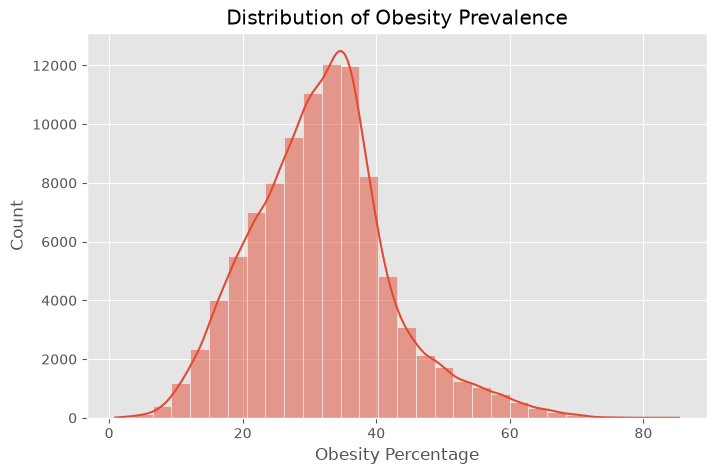

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(df["Data_Value"], bins=30, kde=True)

plt.title("Distribution of Obesity Prevalence")
plt.xlabel("Obesity Percentage")

plt.show()

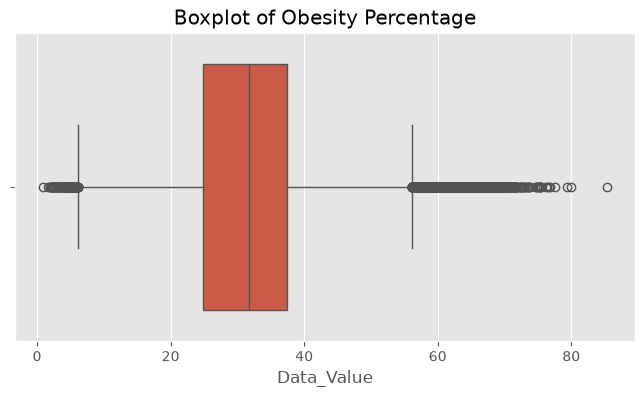

In [37]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Data_Value"])

plt.title("Boxplot of Obesity Percentage")

plt.show()

In [38]:
print("Skewness :", df["Data_Value"].skew())

Skewness : 0.4594236411103621


In [39]:
print("Kurtosis :", df["Data_Value"].kurt())

Kurtosis : 0.6629367602848091


In [40]:
numeric = df.select_dtypes(include=["int64","float64"])

corr = numeric.corr()

corr

,YearStart,YearEnd,Data_Value,Data_Value_Alt,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,LocationID
YearStart,1.000000e+00,1.000000e+00,0.093235,0.093235,0.076918,0.101005,-0.012287,2.004020e-14
YearEnd,1.000000e+00,1.000000e+00,0.093235,0.093235,0.076918,0.101005,-0.012287,2.004020e-14
Data_Value,9.323479e-02,9.323479e-02,1.000000,1.000000,0.956595,0.943432,-0.004803,6.350974e-03
Data_Value_Alt,9.323479e-02,9.323479e-02,1.000000,1.000000,0.956595,0.943432,-0.004803,6.350974e-03
Low_Confidence_Limit,7.691785e-02,7.691785e-02,0.956595,0.956595,1.000000,0.807927,0.051040,4.764169e-03
High_Confidence_Limit,1.010047e-01,1.010047e-01,0.943432,0.943432,0.807927,1.000000,-0.063047,8.587197e-03
Sample_Size,-1.228750e-02,-1.228750e-02,-0.004803,-0.004803,0.051040,-0.063047,1.000000,1.510527e-01
LocationID,2.004020e-14,2.004020e-14,0.006351,0.006351,0.004764,0.008587,0.151053,1.000000e+00


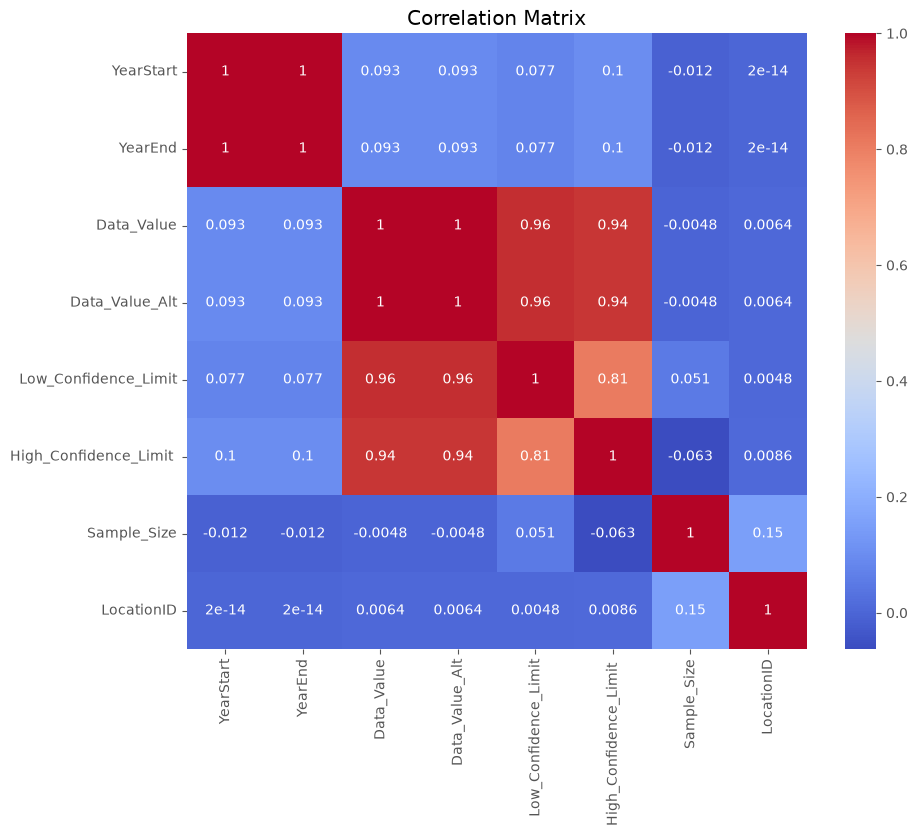

In [41]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

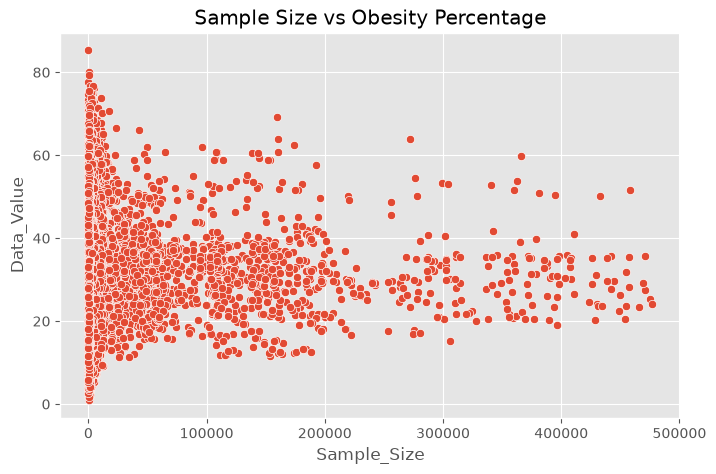

In [42]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Sample_Size",
    y="Data_Value"
)

plt.title("Sample Size vs Obesity Percentage")

plt.show()

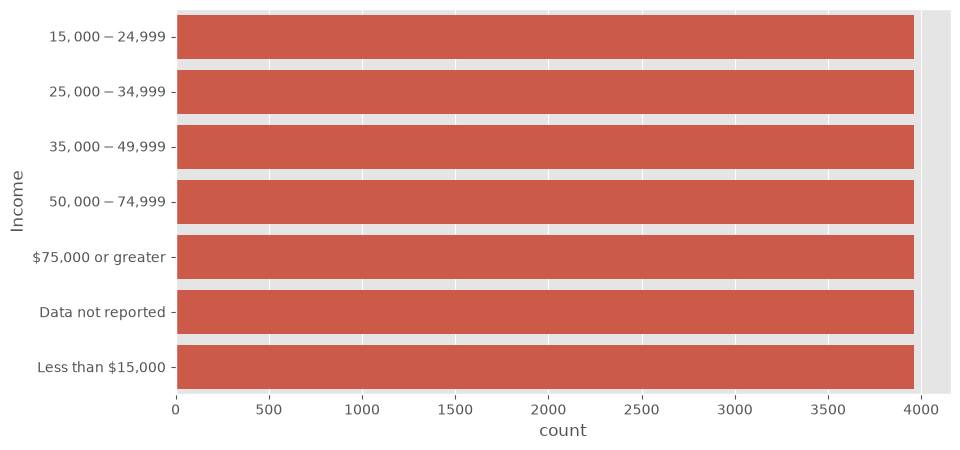

In [43]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="Income"
)

plt.show()

In [44]:
constant_columns = []

for col in df.columns:
    if df[col].nunique(dropna=False) == 1:
        constant_columns.append(col)

constant_columns

['Datasource', 'Data_Value_Type', 'DataValueTypeID']

In [45]:
(df["Data_Value"] == df["Data_Value_Alt"]).all()

np.False_

In [46]:
(df["Data_Value"] == df["Data_Value_Alt"]).all()

np.False_

In [47]:
df["Data_Value"].equals(df["Data_Value_Alt"])

True

In [48]:
different = df[df["Data_Value"] != df["Data_Value_Alt"]]

different[["Data_Value", "Data_Value_Alt"]].head(20)

,Data_Value,Data_Value_Alt
13,NaN,NaN
17,NaN,NaN
25,NaN,NaN
41,NaN,NaN
45,NaN,NaN
51,NaN,NaN
73,NaN,NaN
81,NaN,NaN
97,NaN,NaN
101,NaN,NaN


In [49]:
df["Data_Value"].equals(df["Data_Value_Alt"])

True

In [53]:
df["Data_Value"].equals(df["Data_Value_Alt"])

True

In [51]:
df[df["Data_Value"] != df["Data_Value_Alt"]][["Data_Value", "Data_Value_Alt"]].head(10)

,Data_Value,Data_Value_Alt
13,NaN,NaN
17,NaN,NaN
25,NaN,NaN
41,NaN,NaN
45,NaN,NaN
51,NaN,NaN
73,NaN,NaN
81,NaN,NaN
97,NaN,NaN
101,NaN,NaN


In [55]:
df.loc[
    different,
    ["Data_Value", "Data_Value_Alt"]
].head(20)

ValueError: Cannot index with multidimensional key

In [56]:
print(df["Data_Value"].equals(df["Data_Value_Alt"]))

True


In [57]:
mask = df["Data_Value"].fillna(-9999) != df["Data_Value_Alt"].fillna(-9999)

print(mask.sum())

0


In [58]:
df.loc[mask, ["Data_Value", "Data_Value_Alt"]].head(20)

,Data_Value,Data_Value_Alt
